[get_dataset_dir] Dataset found in /Users/griegner/nilearn_data/fsaverage4
'pial_mesh.coordinates' shape: (2562, 3)
'pial_mesh.faces' shape: (5120, 3)


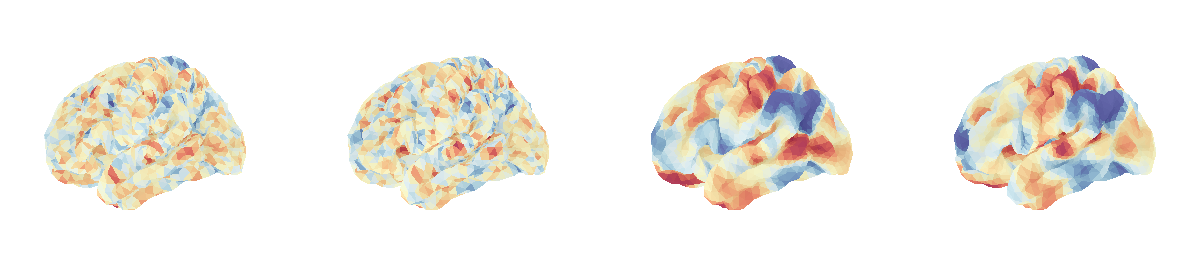

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from nilearn import datasets, plotting
from nilearn.surface import load_surf_mesh

from compare_brain_maps import surface

fsaverage = datasets.fetch_surf_fsaverage(mesh="fsaverage4")
surface_mesh = load_surf_mesh(fsaverage.pial_left)
print(
    f"'pial_mesh.coordinates' shape: {surface_mesh.coordinates.shape}",
    f"'pial_mesh.faces' shape: {surface_mesh.faces.shape}",
    sep="\n",
)

# initialize parameters
rng = np.random.default_rng(seed=0)
n_vertices = surface_mesh.coordinates.shape[0]

# simulate map0 and map1 with correlation rho
rho = 0.6
maps = rng.multivariate_normal([0, 0], [[1, rho], [rho, 1]], size=n_vertices)
maps = maps - maps.mean(axis=0)  # mean center
maps_smoothed = surface.smooth_surface_data(surface_mesh, maps, iterations=8, match="dist")

# plot map0 and map1
fig, axs = plt.subplots(1, 4, figsize=(15, 4), subplot_kw=dict(projection="3d"))
plot_surf_kwargs = dict(bg_map=fsaverage.sulc_left, bg_on_data=True, cmap="RdYlBu", vmin=-2, vmax=2)

plotting.plot_surf(surface_mesh, maps[:, 0], axes=axs[0], **plot_surf_kwargs)
plotting.plot_surf(surface_mesh, maps[:, 1], axes=axs[1], **plot_surf_kwargs)
plotting.plot_surf(surface_mesh, maps_smoothed[:, 0], axes=axs[2], **plot_surf_kwargs)
plotting.plot_surf(surface_mesh, maps_smoothed[:, 1], axes=axs[3], **plot_surf_kwargs)
pass  # stop from double-plotting

**full map**

In [2]:
def xcorr(x1, x2):
    """Estimate the sample correlation between two vectors."""
    x1 -= x1.mean()
    x2 -= x2.mean()
    return x1 @ x2 / (x1.std() * x2.std()) / x1.size


# initialize simulation results
n_simulations = 1000
rhos = [0.0, 0.3, 0.6, 0.9]
results = {
    f"{rho}_{suffix}": np.zeros(n_simulations)
    for rho in rhos
    for suffix in ["maps", "maps-smoothed"]
}

for rho in rhos:
    for i in range(n_simulations):
        # generate maps
        maps = rng.multivariate_normal([0, 0], [[1, rho], [rho, 1]], size=n_vertices)
        maps_smoothed = surface.smooth_surface_data(surface_mesh, maps, iterations=3, match="dist")

        # estimate rho hats
        rho_hat = xcorr(maps[:, 0], maps[:, 1])
        rho_hat_smoothed = xcorr(maps_smoothed[:, 0], maps_smoothed[:, 1])

        # save estimates for plotting
        results[f"{rho}_maps"][i] = rho_hat
        results[f"{rho}_maps-smoothed"][i] = rho_hat_smoothed

**subsampled map**

In [3]:
# !!! 30 sec runtime !!!


def subsample_vertices(adj_matrix, n_iterations=1, seed=1):
    """subsample a patch adjacent vertices"""
    rng = np.random.default_rng(seed=seed)
    n_vertices = adj_matrix.shape[0]

    patch = np.zeros(n_vertices)
    patch[rng.integers(0, n_vertices)] = 1

    for _ in range(n_iterations):
        patch = (adj_matrix @ patch) > 0

    return patch


# set parameters
n_simulations = 1000
n_subsamples = 25
n_iterations = 15
rhos = [0.0, 0.3, 0.6, 0.9]

adj_matrix = surface._compute_adjacency_matrix(surface_mesh)
patch = subsample_vertices(adj_matrix, n_iterations=n_iterations, seed=40)

results_subsample = {
    f"{rho}_{suffix}": np.zeros(n_simulations * n_subsamples)
    for rho in rhos
    for suffix in ["maps", "maps-smoothed"]
}

for rho in rhos:
    for i in range(n_simulations):
        # generate maps
        maps = rng.multivariate_normal([0, 0], [[1, rho], [rho, 1]], size=n_vertices)
        maps_smoothed = surface.smooth_surface_data(surface_mesh, maps, iterations=3, match="dist")

        # estimate rho hats
        for j in range(n_subsamples):

            patch = subsample_vertices(adj_matrix, n_iterations=n_iterations, seed=i + j)

            rho_hat = xcorr(maps[patch, 0], maps[patch, 1])
            rho_hat_smoothed = xcorr(maps_smoothed[patch, 0], maps_smoothed[patch, 1])

            # save estimates for plotting
            results_subsample[f"{rho}_maps"][i * n_subsamples + j] = rho_hat
            results_subsample[f"{rho}_maps-smoothed"][i * n_subsamples + j] = rho_hat_smoothed

**plot simulations**

Text(0.5, 0, '$\\hat{\\rho}_\\text{smoothed}$')

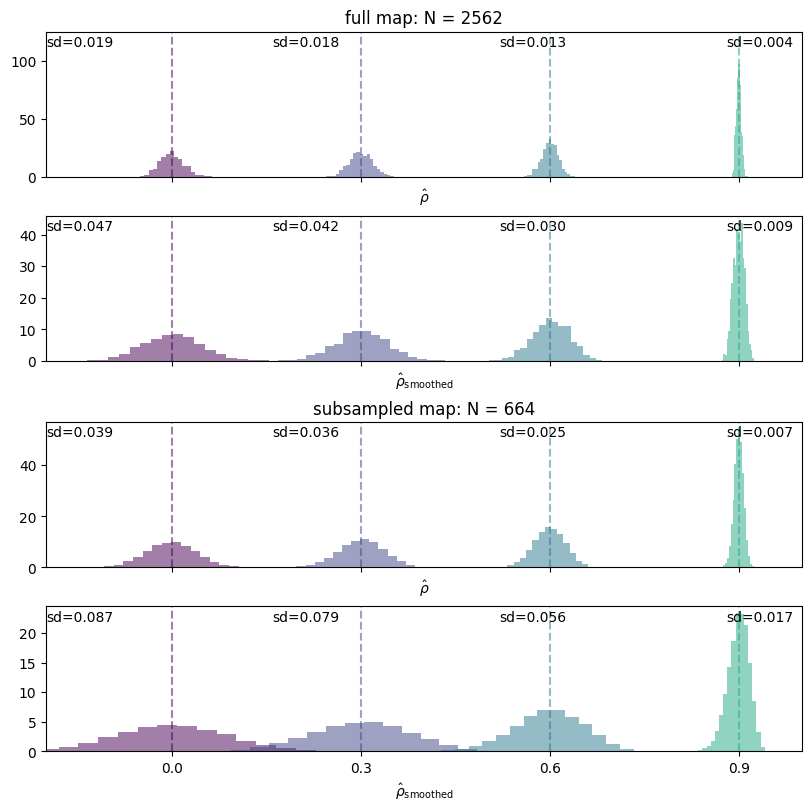

In [4]:
colors = plt.cm.viridis(np.linspace(0, 1, len(rhos) + 2))
hist_kwargs = dict(bins=20, alpha=0.5, density=True)
vline_kwargs = dict(ls="--", alpha=0.5)

fig, axs = plt.subplots(nrows=4, figsize=(8, 8), sharex=True, constrained_layout=True)
for rho, color in zip(rhos, colors):

    # full map
    axs[0].hist(results[f"{rho}_maps"], color=color, **hist_kwargs)
    axs[0].axvline(rho, color=color, **vline_kwargs)
    axs[0].annotate(
        f"sd={results[f"{rho}_maps"].std():.3f}", xy=(rho, 0.9), xycoords="axes fraction"
    )
    axs[1].hist(results[f"{rho}_maps-smoothed"], color=color, **hist_kwargs)
    axs[1].axvline(rho, color=color, **vline_kwargs)
    axs[1].annotate(
        f"sd={results[f"{rho}_maps-smoothed"].std():.3f}", xy=(rho, 0.9), xycoords="axes fraction"
    )

    # subsampled map
    axs[2].hist(results_subsample[f"{rho}_maps"], color=color, **hist_kwargs)
    axs[2].axvline(rho, color=color, **vline_kwargs)
    axs[2].annotate(
        f"sd={results_subsample[f"{rho}_maps"].std():.3f}", xy=(rho, 0.9), xycoords="axes fraction"
    )
    axs[3].hist(results_subsample[f"{rho}_maps-smoothed"], color=color, **hist_kwargs)
    axs[3].axvline(rho, color=color, **vline_kwargs)
    axs[3].annotate(
        f"sd={results_subsample[f"{rho}_maps-smoothed"].std():.3f}",
        xy=(rho, 0.9),
        xycoords="axes fraction",
    )

[ax.set_xticks(rhos) for ax in axs]
[ax.set_xlim(-0.2, 1) for ax in axs]

axs[0].set_title(f"full map: N = {n_vertices}")
axs[0].set_xlabel(r"$\hat{\rho}$")
axs[1].set_xlabel(r"$\hat{\rho}_\text{smoothed}$")

axs[2].set_title(f"subsampled map: N = {patch.sum()}")
axs[2].set_xlabel(r"$\hat{\rho}$")
axs[3].set_xlabel(r"$\hat{\rho}_\text{smoothed}$")